# Astroquímica da Nebulosa de Órion — Identificação de moléculas na região OMC-1

**Autores:** Thayllan Anthony de Oliveira · Rafael Ramon Ferreira
**Instituição:** Instituto Federal do Triângulo Mineiro (IFTM)

Este notebook acompanha o artigo submetido à revista *Physicæ Organum* (UnB) e foi
escrito com finalidade **didática**: cada etapa está comentada para que estudantes de
licenciatura (Química, Física, Ciências) possam reproduzir, entender e adaptar a análise.

## O que vamos fazer

Partindo de um cubo de dados do observatório **ALMA** (formato FITS), vamos:

1. **Carregar** o cubo de dados tridimensional (2 eixos espaciais + 1 eixo de frequência).
2. **Mapear** espacialmente a nuvem e localizar o pixel de emissão máxima.
3. **Extrair** o espectro de rádio nesse pixel.
4. **Identificar** as moléculas (*Line ID*) consultando os catálogos JPL e CDMS.
5. **Filtrar** os candidatos com um critério físico (energia do nível superior).
6. **Converter** a posição do pixel em coordenadas celestes (RA/Dec).

> **Pré-requisitos:** noções básicas de Python (listas, funções, gráficos) e de
> espectroscopia (o que é uma linha de emissão). Não é necessário conhecimento prévio
> de astronomia — os conceitos são introduzidos ao longo do caminho.

## Como executar

Você pode rodar tanto no **Google Colab** quanto localmente. Basta ajustar a variável
`PASTA_DADOS` na célula de configuração. Cada bloco de código gera, quando aplicável,
uma figura salva na pasta `figuras/`, na mesma pasta do notebook.

## Etapa 0 — Configuração do ambiente

Instalamos e importamos as bibliotecas. Trabalhamos com poucas ferramentas, todas
gratuitas e amplamente usadas em astronomia:

| Biblioteca | Para que serve |
|---|---|
| `numpy` | operações numéricas com matrizes (o cubo de dados é uma matriz 3D) |
| `matplotlib` | geração dos gráficos |
| `pandas` | organização das tabelas de moléculas |
| `astropy` | leitura de arquivos FITS e conversão de coordenadas (WCS) |
| `astroquery` | consulta aos catálogos moleculares JPL/CDMS via Splatalogue |

> No Colab, `astroquery` normalmente não vem instalado; por isso a primeira linha o instala.

In [1]:
# Instala a biblioteca de consulta a catálogos (necessário no Google Colab).
# O "-q" deixa a saída silenciosa. Se já estiver instalada, nada acontece.
%pip install -q astroquery

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astroquery.splatalogue import Splatalogue
from matplotlib.ticker import AutoMinorLocator

from astropy.utils.data import download_file
import shutil


# Estilo SuperMongo: serifada, ticks para dentro nos 4 lados, sem grade.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 12,
    "axes.linewidth": 1.2,      # moldura mais firme
    "axes.grid": False,         # SuperMongo não usa grade
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,          # ticks nos 4 lados
    "ytick.right": True,
    "xtick.major.size": 7, "xtick.minor.size": 4,
    "ytick.major.size": 7, "ytick.minor.size": 4,
    "xtick.major.width": 1.0, "ytick.major.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

def estilo_sm(ax):
    """Aplica o acabamento SuperMongo a um eixo: minor ticks e moldura fechada."""
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    for lado in ax.spines.values():
        lado.set_linewidth(1.2)

print("Ambiente configurado com sucesso (estilo SuperMongo).")

Note: you may need to restart the kernel to use updated packages.
Ambiente configurado com sucesso (estilo SuperMongo).


### Onde ficam os dados e as figuras

Definimos dois caminhos em um único lugar, para não repetir strings pelo notebook:

- `PASTA_DADOS`: onde o cubo FITS será baixado/lido.
- `PASTA_FIGURAS`: onde as figuras serão salvas (`figuras/`, ao lado do notebook).

Se estiver no **Colab** e quiser guardar os dados no seu Drive, monte-o com o código
comentado abaixo e ajuste `PASTA_DADOS`.

In [2]:
# --- Ambiente local (padrão) ---
PASTA_DADOS = "dados"
PASTA_FIGURAS = "figuras"

# --- Alternativa: Google Drive no Colab (descomente se desejar) ---
# from google.colab import drive
# drive.mount("/content/drive")
# PASTA_DADOS = "/content/drive/MyDrive/OMC-1/dados"

os.makedirs(PASTA_DADOS, exist_ok=True)
os.makedirs(PASTA_FIGURAS, exist_ok=True)

ARQUIVO_CUBO = os.path.join(PASTA_DADOS, "orion_cubo.fits")
print("Dados  ->", PASTA_DADOS)
print("Figuras->", PASTA_FIGURAS)

Dados  -> dados
Figuras-> figuras


## Etapa 1 — Download do cubo de dados do ALMA

O arquivo `OMC-1_Region5_sci.spw18.cube.I.pbcor.fits` é um **cubo de dados**: imagine
uma pilha de imagens do céu, uma para cada frequência observada. Ele vem do arquivo
público do ALMA.

> O download só acontece se o arquivo ainda não existir localmente — assim você não
> baixa de novo a cada execução.

In [3]:
URL_ALMA = "https://almascience.eso.org/dataPortal/member.uid___A001_X1292_X14a.OMC-1_Region5_sci.spw18.cube.I.pbcor.fits"

if not os.path.exists(ARQUIVO_CUBO):
    print("Baixando o cubo de dados do ALMA...")
    # --progress=bar:force mostra a barra mesmo dentro do notebook
    !wget --progress=bar:force -O "$ARQUIVO_CUBO" "$URL_ALMA"
    print("Download concluído.")
else:
    print("Cubo já existe localmente — pulando o download.")

Baixando o cubo de dados do ALMA...
--2026-09-15 15:26:49--  https://almascience.eso.org/dataPortal/member.uid___A001_X1292_X14a.OMC-1_Region5_sci.spw18.cube.I.pbcor.fits
Resolving almascience.eso.org (almascience.eso.org)... 134.171.46.218
Connecting to almascience.eso.org (almascience.eso.org)|134.171.46.218|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 1414848960 (1.3G) [image/x-fits]
Saving to: 'dados/orion_cubo.fits'

dados/orion_cubo.fi 100%[===================>]   1.32G  13.4MB/s    in 1m 43s  

2026-09-15 15:28:34 (13.1 MB/s) - 'dados/orion_cubo.fits' saved [1414848960/1414848960]

Download concluído.


## Etapa 2 — Carregando o cubo e entendendo sua estrutura

Um arquivo FITS tem duas partes: o **cabeçalho** (metadados: dimensões, frequência de
referência, coordenadas) e os **dados** (a matriz numérica).

A dimensão do cubo do ALMA costuma ser `(1, N_freq, N_y, N_x)` — o primeiro eixo é a
*polarização*, que não usaremos. Vamos removê-lo para ficar com um cubo 3D limpo:
`(N_freq, N_y, N_x)`.

Para evitar reabrir o arquivo várias vezes, criamos uma **função** que carrega o cubo e
já devolve o cabeçalho junto.

In [4]:
def carregar_cubo(caminho):
    """Le um cubo FITS do ALMA e devolve (cubo_3d, cabecalho).

    Remove o eixo de polarizacao, se existir, deixando (N_freq, N_y, N_x).
    """
    with fits.open(caminho) as hdul:
        hdul.info()                      # imprime a estrutura do arquivo
        dados = hdul[0].data
        cabecalho = hdul[0].header
    # data.ndim == 4  ->  (pol, freq, y, x); pegamos o indice 0 da polarizacao.
    cubo_3d = dados[0] if dados.ndim == 4 else dados
    return cubo_3d, cabecalho


cubo, header = carregar_cubo(ARQUIVO_CUBO)
print("\nDimensões do cubo 3D (freq, y, x):", cubo.shape)

Filename: dados/orion_cubo.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      92   (288, 320, 3838, 1)   float32   

Dimensões do cubo 3D (freq, y, x): (3838, 320, 288)


### Construindo o eixo de frequência

O cabeçalho guarda três números que descrevem o eixo espectral, seguindo a convenção
**WCS** (*World Coordinate System*):

- `CRVAL3`: frequência no pixel de referência (em Hz);
- `CDELT3`: quanto a frequência muda de um canal para o próximo (em Hz);
- `CRPIX3`: qual canal é o de referência.

Com eles convertemos o "número do canal" em **frequência física** (GHz). Encapsulamos
isso em uma função porque será reutilizada nos próximos gráficos.

In [5]:
def eixo_frequencia_ghz(header, n_canais):
    """Converte numeros de canal em frequencia (GHz) usando o WCS do cabecalho."""
    crval = header["CRVAL3"]        # frequencia de referencia (Hz)
    cdelt = header["CDELT3"]        # passo entre canais (Hz)
    crpix = header["CRPIX3"]        # canal de referencia (base 1)
    canais = np.arange(n_canais)
    freq_hz = crval + (canais - (crpix - 1)) * cdelt
    return freq_hz / 1e9            # Hz -> GHz


freq_ghz = eixo_frequencia_ghz(header, cubo.shape[0])
print(f"Faixa de frequência observada: {freq_ghz.min():.3f} a {freq_ghz.max():.3f} GHz")
print(f"Número de canais espectrais: {cubo.shape[0]}")

Faixa de frequência observada: 232.141 a 234.014 GHz
Número de canais espectrais: 3838


## Etapa 3 — Localizando a fonte: mapa espacial e pixel de emissão máxima

A emissão da nuvem não está no centro da imagem. Para achar o ponto mais brilhante,
colapsamos o eixo de frequência tomando, para cada pixel do céu, a **intensidade máxima**
ao longo de todos os canais. Isso gera um **mapa 2D** (uma "foto" da nuvem).

Em seguida, `np.nanargmax` encontra automaticamente as coordenadas `(x, y)` do pixel
mais intenso — a nossa **"Região 5"**.

> Usamos as versões `nan*` (`nanmax`, `nanargmax`) porque cubos do ALMA contêm pixels
> vazios marcados como `NaN` nas bordas; essas funções os ignoram.

In [6]:
# Mapa de intensidade maxima: "achata" o eixo espectral (axis=0).
mapa_max = np.nanmax(cubo, axis=0)

# Coordenadas (y, x) do pixel mais brilhante de todo o cubo.
y_pico, x_pico = np.unravel_index(np.nanargmax(mapa_max), mapa_max.shape)
print(f"Pixel de emissão máxima -> X = {x_pico}, Y = {y_pico}")

# Espectro extraido exatamente nesse pixel.
espectro_pico = cubo[:, y_pico, x_pico]
fluxo_pico = np.nanmax(espectro_pico)
print(f"Fluxo no pico: {fluxo_pico:.2f} Jy/beam")

Pixel de emissão máxima -> X = 110, Y = 289
Fluxo no pico: 13.30 Jy/beam


/var/folders/1m/whc0_ck14x37_09_jw61tblc0000gn/T/ipykernel_8221/3950828775.py:2: RuntimeWarning: All-NaN slice encountered
  mapa_max = np.nanmax(cubo, axis=0)


### Figura — mapa espacial + espectro no pixel de pico

Geramos a figura de dois painéis usada no artigo: à esquerda o mapa da nuvem com o pixel
de pico destacado; à direita o espectro extraído nesse ponto. A figura é salva em
`figuras/fig3_mapa_espectro.png`.

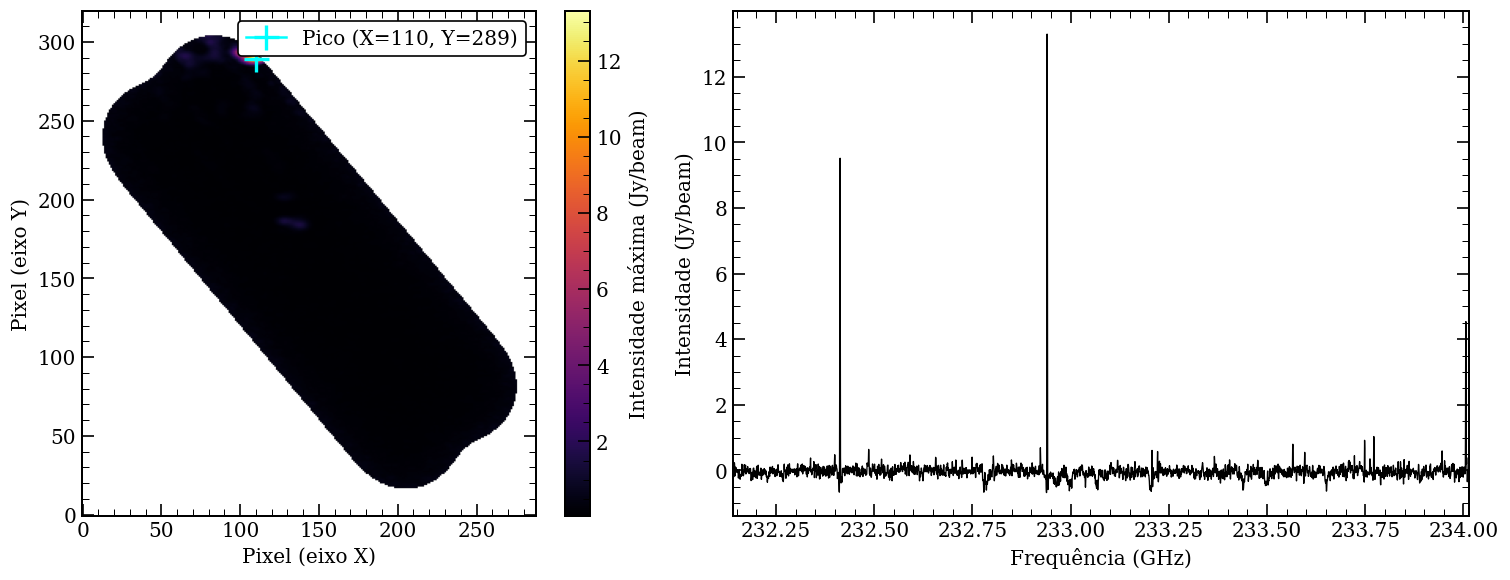

Figura salva em figuras/fig3_mapa_espectro.(png|pdf)


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Painel esquerdo: mapa espacial ---
im = ax1.imshow(mapa_max, origin="lower", cmap="inferno")
ax1.plot(x_pico, y_pico, marker="+", color="cyan", markersize=15,
         markeredgewidth=2.0, label=f"Pico (X={x_pico}, Y={y_pico})")
ax1.set_xlabel("Pixel (eixo X)")
ax1.set_ylabel("Pixel (eixo Y)")
ax1.legend(loc="upper right", frameon=True, framealpha=1.0, edgecolor="black")
cbar = fig.colorbar(im, ax=ax1, label="Intensidade máxima (Jy/beam)",
                    fraction=0.046, pad=0.04)
cbar.ax.tick_params(direction="in")
estilo_sm(ax1)

# --- Painel direito: espectro no pixel de pico ---
ax2.plot(freq_ghz, espectro_pico, color="black", linewidth=0.8)
ax2.set_xlabel(r"Frequência (GHz)")
ax2.set_ylabel("Intensidade (Jy/beam)")
ax2.set_xlim(freq_ghz.min(), freq_ghz.max())
ax2.ticklabel_format(useOffset=False, style="plain")
estilo_sm(ax2)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_FIGURAS, "fig3_mapa_espectro.png"))
plt.savefig(os.path.join(PASTA_FIGURAS, "fig3_mapa_espectro.pdf"))
plt.show()
print("Figura salva em figuras/fig3_mapa_espectro.(png|pdf)")

## Etapa 4 — Espectro normalizado com as linhas de emissão

Para visualizar melhor as três linhas de emissão, normalizamos o espectro dividindo pelo
seu valor máximo (assim o pico vale 1). Anotamos os três picos com os nomes das moléculas
que serão identificadas nas próximas etapas. Esta é a **Figura 2** do artigo.

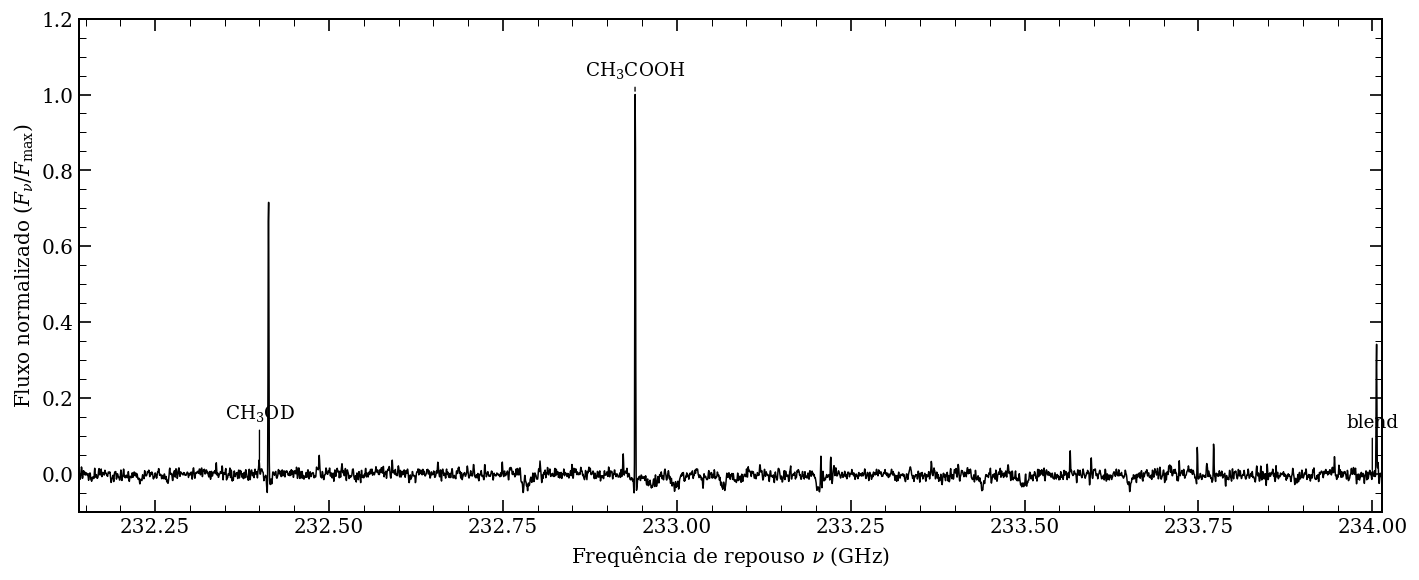

Figura salva em figuras/fig2_espectro_normalizado.(png|pdf)


In [8]:
espectro_norm = espectro_pico / np.nanmax(np.abs(espectro_pico))

picos = {
    232.40: r"CH$_3$OD",
    232.94: r"CH$_3$COOH",
    234.00: r"blend",
}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(freq_ghz, espectro_norm, color="black", linewidth=0.9)

for f, rotulo in picos.items():
    idx = np.argmin(np.abs(freq_ghz - f))
    altura = espectro_norm[idx]
    ax.annotate(rotulo, xy=(f, altura), xytext=(f, min(altura + 0.12, 1.05)),
                ha="center", fontsize=11,
                arrowprops=dict(arrowstyle="-", lw=0.8, color="black"))

ax.set_xlabel(r"Frequência de repouso $\nu$ (GHz)")
ax.set_ylabel(r"Fluxo normalizado ($F_\nu / F_{\mathrm{max}}$)")
ax.set_xlim(freq_ghz.min(), freq_ghz.max())
ax.set_ylim(-0.1, 1.2)
estilo_sm(ax)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_FIGURAS, "fig2_espectro_normalizado.png"))
plt.savefig(os.path.join(PASTA_FIGURAS, "fig2_espectro_normalizado.pdf"))
plt.show()
print("Figura salva em figuras/fig2_espectro_normalizado.(png|pdf)")

## Etapa 5 — Identificação das moléculas (*Line ID*)

Agora respondemos: **quais moléculas produzem cada linha?** Consultamos os catálogos
internacionais **JPL** (*Jet Propulsion Laboratory*) e **CDMS** (*Cologne Database for
Molecular Spectroscopy*) através da plataforma **Splatalogue**, usando a `astroquery`.

Para cada pico, abrimos uma **janela estreita de frequência** ao redor dele. A janela
precisa ter uma pequena folga porque a nuvem se move (efeito Doppler), deslocando
levemente as frequências observadas em relação às de laboratório.

Cada consulta pode retornar **dezenas a centenas** de transições teoricamente possíveis.
Por isso, aplicamos um **filtro físico**: só faz sentido uma molécula emitir com força se
seu nível de energia superior ($E_u/k$) for compatível com a temperatura do gás. Nos
núcleos quentes de Órion, as temperaturas de excitação vão de ~150 K a ~300 K; adotamos
o limite conservador de **$E_u/k < 500$ K**, abaixo do qual a excitação térmica é
estatisticamente relevante (distribuição de Boltzmann).

In [9]:
# Colunas uteis retornadas pelo Splatalogue.
COLUNAS = ["name", "chemical_name", "orderedfreq", "upper_state_energy_K"]
LIMITE_ENERGIA_K = 500  # filtro termodinamico (Boltzmann)

def investigar_pico(freq_min_ghz, freq_max_ghz, limite_k=LIMITE_ENERGIA_K):
    """Consulta JPL/CDMS numa janela de frequencia e aplica o filtro de energia.

    Retorna um DataFrame com as moleculas candidatas (Eu/k < limite_k), ou None.
    """
    print(f"Buscando entre {freq_min_ghz} e {freq_max_ghz} GHz...")
    try:
        tabela = Splatalogue.query_lines(
            freq_min_ghz * u.GHz, freq_max_ghz * u.GHz,
            line_lists=["JPL", "CDMS"],
        )
        if len(tabela) == 0:
            print("Nenhuma transição encontrada nesta janela.\n")
            return None

        df = tabela.to_pandas()
        # Mantem apenas as colunas que existem (nomes podem variar entre versoes).
        cols = [c for c in COLUNAS if c in df.columns]
        df = df[cols]

        # Filtro termodinamico: energia do nivel superior abaixo do limite.
        if "upper_state_energy_K" in df.columns:
            df = df[df["upper_state_energy_K"] < limite_k]

        if df.empty:
            print(f"Nenhuma molécula sobreviveu ao filtro (Eu/k < {limite_k} K).\n")
            return None
        return df.reset_index(drop=True)

    except Exception as erro:
        print(f"Erro durante a consulta: {erro}\n")
        return None

### Pico central (232.94 GHz) — o mais intenso

Começamos pela linha mais forte do espectro.

In [10]:
cand_central = investigar_pico(232.93, 232.95)
cand_central

Buscando entre 232.93 e 232.95 GHz...


,name,chemical_name,orderedfreq,upper_state_energy_K
0,"CH<sub>3</sub>COOH <font color=""red"">v=0</font>",Acetic Acid,232930.0834,333.73499
1,"CH<sub>3</sub>COOH <font color=""red"">v=0</font>",Acetic Acid,232930.0834,333.73499
2,"CH<sub>3</sub>COOH <font color=""red"">v=0</font>",Acetic Acid,232930.0834,333.73499
3,"CH<sub>3</sub>COOH <font color=""red"">v=0</font>",Acetic Acid,232930.0834,333.73499
4,NCHCCO,Cyanoethenone,232930.0900,265.60659
...,...,...,...,...
104,CH<sub>3</sub>CHNH<sub>2</sub>COOH - I,&alpha;-Alanine,232948.1501,473.84970
105,C<sub>3</sub>H<sub>8</sub>,Propane,232948.2606,406.95512
106,<i>AA</i>-<i>n</i>-C<sub>4</sub>H<sub>9</sub>CN,n-Butyl cyanide,232948.5164,97.09005
107,<i>AA</i>-<i>n</i>-C<sub>4</sub>H<sub>9</sub>CN,n-Butyl cyanide,232948.5164,97.09005


### Picos laterais (232.40 GHz e 234.00 GHz)

Repetimos a busca nos outros dois picos. O de 234.00 GHz é um caso interessante de
**sobreposição de linhas** (*blending*): mais de uma molécula pode contribuir para a
mesma frequência observada.

In [11]:
print("=== PICO 1 — 232.40 GHz ===")
cand_pico1 = investigar_pico(232.398, 232.402)
display(cand_pico1)

print("=== PICO 3 — 234.00 GHz (possível blend) ===")
cand_pico3 = investigar_pico(233.998, 234.002)
display(cand_pico3)

=== PICO 1 — 232.40 GHz ===
Buscando entre 232.398 e 232.402 GHz...


,name,chemical_name,orderedfreq,upper_state_energy_K
0,HCCCH<sub>2</sub>CN,Propargyl cyanide,232398.5948,266.68664
1,D2NCH2CN,Aminoacetonitrile,232398.8883,481.94376
2,D2NCH2CN,Aminoacetonitrile,232398.8883,481.94376
3,CH<sub>3</sub>CH<sub>2</sub>CH<sub>2</sub>CN-g...,Butyronitrile,232399.3332,164.39760
4,"CH<sub>3</sub>OD <font color=""red"">v = 0</font>",Methanol,232400.3126,382.13342
5,S<sub>4</sub>,Tetrasulfur,232400.4634,436.20006
6,gGG'g-CH2OHCH2CH2OH,"1,3-propanediol, gGG'g",232400.5192,178.00225
7,HOONO<sub>2</sub>,Peroxynitric acid,232400.6871,65.36175
8,gGG'g-CH2OHCH2CH2OH,"1,3-propanediol, gGG'g",232400.8961,178.00054
9,C<sub>2</sub>H<sub>5</sub>OOCH-<i>trans</i>,Ethyl formate,232401.1666,114.71773


=== PICO 3 — 234.00 GHz (possível blend) ===
Buscando entre 233.998 e 234.002 GHz...


,name,chemical_name,orderedfreq,upper_state_energy_K
0,<i>c</i>-C<sub>5</sub>H<sub>6</sub>O,Cyclopentadieneoxide,233998.7938,391.63191
1,<i>GA</i>-<i>n</i>-C<sub>4</sub>H<sub>9</sub>CN,n-Butyl cyanide,233998.9307,465.53072
2,<i>c</i>-C<sub>5</sub>H<sub>6</sub>O,Cyclopentadieneoxide,233999.5000,391.63194
3,"O<sub>2</sub><sup>17</sup>O-sym, v<sub>2</sub>...",Ozone,233999.7575,172.56863
4,"O<sub>2</sub><sup>17</sup>O-sym, v<sub>2</sub>...",Ozone,233999.8901,172.56864
5,t-HC(O)SH,Monothiformic acid,233999.9775,290.26247
6,t-HC(O)SH,Monothiformic acid,233999.9775,290.26247
7,13CH2OHCHO,Glycolaldehyde,233999.9867,45.23199
8,"O<sub>2</sub><sup>17</sup>O-sym, v<sub>2</sub>...",Ozone,233999.9990,172.56865
9,"O<sub>2</sub><sup>17</sup>O-sym, v<sub>2</sub>...",Ozone,234000.0832,172.56865


## Etapa 6 — Tabela final das moléculas identificadas

Após a consulta aos catálogos, o filtro termodinâmico e uma triagem contextual
qualitativa (descartando espécies simétricas sem momento de dipolo, isotopólogos muito
raros e moléculas incompatíveis com o ambiente), consolidamos as identificações mais
prováveis. Esta é a **Tabela 1** do artigo, salva também em CSV na pasta de dados.

In [12]:
tabela_final = pd.DataFrame({
    "Molécula identificada": [
        "Metanol deuterado (CH3OD)",
        "Ácido acético (CH3COOH)",
        "Glicolaldeído isotópico (13CH2OHCHO)*",
        "Ácido monotiofórmico (t-HC(O)SH)*",
    ],
    "Frequência observada (GHz)": ["~232.40", "~232.94", "~234.00", "~234.00"],
    "Frequência de repouso (MHz)": [232400.31, 232940.37, 233999.98, 233999.97],
    "Energia Eu/k (K)": [382.13, 284.22, 45.23, 290.26],
})

caminho_csv = os.path.join(PASTA_DADOS, "tabela_identificacao_moleculas.csv")
tabela_final.to_csv(caminho_csv, index=False, sep=";")
print(f"Tabela salva em {caminho_csv}")
print("(*) Par de candidatas para a linha sobreposta (blend) em 234.00 GHz.\n")
tabela_final

Tabela salva em dados/tabela_identificacao_moleculas.csv
(*) Par de candidatas para a linha sobreposta (blend) em 234.00 GHz.



,Molécula identificada,Frequência observada (GHz),Frequência de repouso (MHz),Energia Eu/k (K)
0,Metanol deuterado (CH3OD),~232.40,232400.31,382.13
1,Ácido acético (CH3COOH),~232.94,232940.37,284.22
2,Glicolaldeído isotópico (13CH2OHCHO)*,~234.00,233999.98,45.23
3,Ácido monotiofórmico (t-HC(O)SH)*,~234.00,233999.97,290.26


## Etapa 7 — Onde fica essa região no céu? (coordenadas celestes)

Por fim, traduzimos a posição do pixel `(110, 289)` em **coordenadas astronômicas reais**
— Ascensão Reta (RA) e Declinação (Dec) — usando novamente o WCS do cabeçalho. Isso
permite confirmar que a "Região 5" está próxima ao centro de **Órion KL**, na fronteira
entre o *Hot Core* e o *Compact Ridge*.

In [13]:
X_REGIAO5, Y_REGIAO5 = 110, 289

wcs_celeste = WCS(header).celestial
coord = wcs_celeste.pixel_to_world(X_REGIAO5, Y_REGIAO5)

print("=== COORDENADAS CELESTES DA REGIÃO 5 ===")
print(f"Pixel X={X_REGIAO5}, Y={Y_REGIAO5}")
print("RA :", coord.ra.to_string(unit="hour", sep="hms", precision=2))
print("Dec:", coord.dec.to_string(unit="degree", sep="dms", precision=2))
print("\n=== Referência: centro de Órion KL ===")
print("RA : 05h35m14s   |   Dec: -05d22m30s")

=== COORDENADAS CELESTES DA REGIÃO 5 ===
Pixel X=110, Y=289
RA : 5h35m14.92s
Dec: -5d22m45.62s

=== Referência: centro de Órion KL ===
RA : 05h35m14s   |   Dec: -05d22m30s


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Encerramento — potencial didático

Este notebook percorreu, em poucas etapas e com ferramentas gratuitas, o mesmo caminho
de uma análise astroquímica profissional: **dado bruto → mapa → espectro → identificação
→ interpretação física → localização no céu**.

Sugestões de uso em sala de aula ou iniciação científica:

- **Química:** discutir por que Moléculas Orgânicas Complexas (COMs) surgem em núcleos
  quentes e o papel do fracionamento de deutério.
- **Física:** relacionar o filtro $E_u/k < 500$ K à distribuição de Boltzmann e ao
  conceito de temperatura de excitação.
- **Computação/Ciência de dados:** explorar como um cubo 3D é manipulado com `numpy` e
  como catálogos científicos são consultados por API.
- **Atividade proposta:** trocar a janela de frequência ou o limite de energia e observar
  como o conjunto de moléculas candidatas muda — uma forma concreta de discutir critérios
  de decisão em ciência.

> **Limitação honesta:** a identificação a partir de um único espectro é *preliminar*. A
> confirmação de uma molécula no meio interestelar exige múltiplas linhas de transição e
> consistência espacial — um ótimo ponto de partida para discutir o método científico.